# [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) for MNIST
(J. Ho, A. Jain, P. Abbeel 2020)

![](https://raw.githubusercontent.com/dataflowr/website/master/modules/extras/diffusions/ddpm.png)

In [ ]:
d 

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm.notebook import tqdm
import pyxu.runtime as pxrt
import cupy as cp
import pyxu.opt.stop as pxst
import pyxu.abc as pxa
from utils import *

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(120, 40)


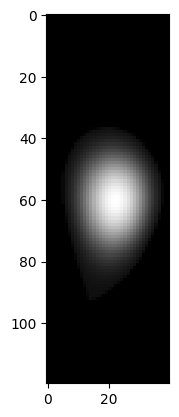

In [3]:
# Load multiple data files with 'x' replaced by indices from 0 to 999
dataset_fusion = []
for x in range(10000):
    dataset_fusion.append(np.load(f'../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{x}.npy'))
dataset_fusion = np.array(dataset_fusion)
plt.imshow(dataset_fusion[125], cmap='gray')
print(dataset_fusion[125].shape)

In [4]:
# test output of nn with random input
model = MyTinyUNet().to(device)
x = torch.randn(2, 1, 32, 32).to(device)
t = torch.randint(0, 1000, (2,)).to(device)
y = model(x, t)
bs = 3
x = torch.randn(bs,1,120,40)
n_steps=1000
timesteps = torch.randint(0, n_steps, (bs,)).long()
unet = MyTinyUNet(in_c =1, out_c =1)
y = unet(x,timesteps)
y.shape
# plt.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
# plt.show()

torch.Size([3, 1, 120, 40])

In [5]:
num_timesteps = 1000
betas = torch.linspace(0.0001, 0.02, num_timesteps, dtype=torch.float32).to(device)

network = MyTinyUNet(in_c =1, out_c =1)
model = DDPM(network, num_timesteps, beta_start=0.0001, beta_end=0.02, device=device)

bs = 5
x = torch.randn(bs,1,120,40).to(device)
timesteps = 10*torch.ones(bs,).long().long().to(device)
y = model.add_noise(x,x,timesteps)
y.shape
y = model.step(x,timesteps[0],x)
y.shape
# for n, p in model.named_parameters():
#     print(n, p.shape)

torch.Size([5, 1, 120, 40])

You can check that all the parameters of the UNet `network` are indeed parameters of the DDPM `model` like this:

In [6]:
dataset_fusion_torch = torch.tensor(dataset_fusion).float().reshape(dataset_fusion.shape[0], 1, dataset_fusion.shape[1], dataset_fusion.shape[2])

transform01 = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        #torchvision.transforms.Normalize((0.5), (0.5))
    ])

dataset = torch.utils.data.TensorDataset(dataset_fusion_torch)
dataloader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True, num_workers=10)

print(len(dataloader))

313


In [7]:
# for b in dataloader:
#     batch = b[0]
#     break

# bn = [b for b in batch[:100]]
 
# show_images(bn, "origin")

In [8]:
import torch
from torch.utils.tensorboard import SummaryWriter # <-- Add this import
%load_ext tensorboard
%tensorboard --logdir runs

train_ = False

if train_ == True:
    learning_rate = 1e-3
    num_epochs = 20 
    num_timesteps = 1000
    
    # Initialize the TensorBoard writer (it creates a 'runs' folder by default)
    writer = SummaryWriter('runs/fusion_ddpm_experiment') 
    
    network = MyTinyUNet().to(device)
    model = DDPM(network, num_timesteps, beta_start=0.0001, beta_end=0.02, device=device)
    optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)
    
    # Pass the writer into your training loop
    training_loop(model, dataloader, optimizer, num_epochs, num_timesteps, device=device, writer=writer)   

    # Close the writer and save the model
    writer.close()
    torch.save(model.state_dict(), 'fusion.pth') 

else:
    model.load_state_dict(torch.load("fusion_epoch_2193.pth", weights_only=True))

Reusing TensorBoard on port 6006 (pid 3666596), started 1 day, 18:55:48 ago. (Use '!kill 3666596' to kill it.)

100%|██████████| 1000/1000 [00:08<00:00, 115.26it/s]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


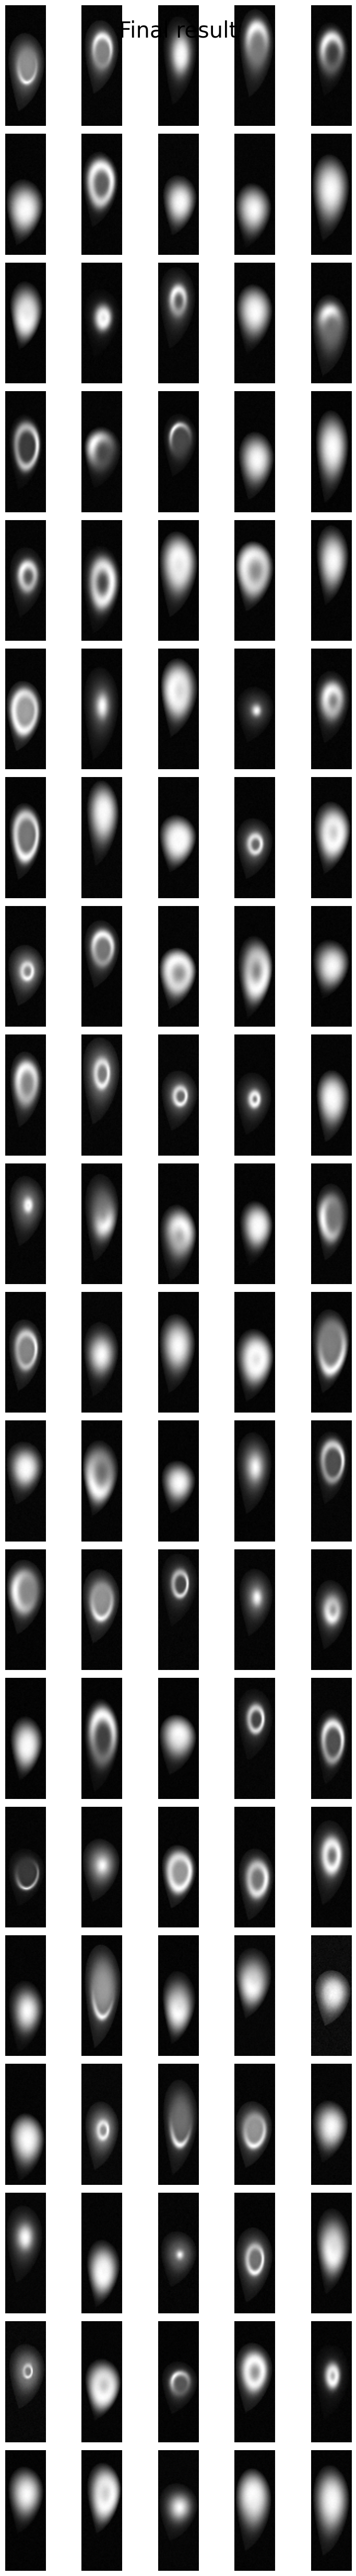

In [9]:
generated, generated_mid = generate_image(model.to(device), 100, 1, (120, 40))
show_images(generated, "Final result")

## Conditional posterior sampling with X-ray projections

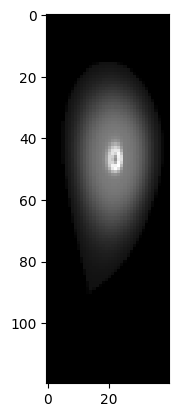

In [10]:
for b in dataloader:
    batch = b[0]
    break
x_gt_np = rescale(batch[10].permute(1,2,0).numpy())
plt.imshow(x_gt_np, cmap="gray")

In [11]:
import cupy as cp
x_gt_np_ = x_gt_np[:,:,0]
v_shape = x_gt_np_.shape
x_gt_cp = torch.tensor(x_gt_np_, device = device).reshape(-1)


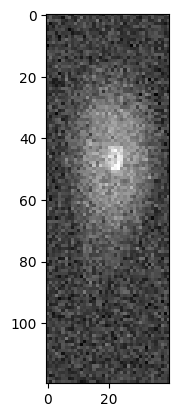

In [42]:
import scipy.sparse as sp
import cupyx.scipy.sparse as csp

# load operator
A_np = sp.load_npz("forward_model/sparse_mat_artificial_coarse_random_1e4.npz")
A_cp = csp.csr_matrix(A_np)
A_dense = A_cp.todense()
A_torch = torch.tensor(A_dense).float().to(device)

# test denoising
A_torch = torch.eye(A_torch.shape[1], device=device)

y = A_torch @ x_gt_cp + 0.05*torch.randn(A_torch.shape[0], device=device)

back_proj = A_torch.T @ y.reshape(-1)
plt.imshow(back_proj.reshape(120,40).cpu(), cmap="gray")

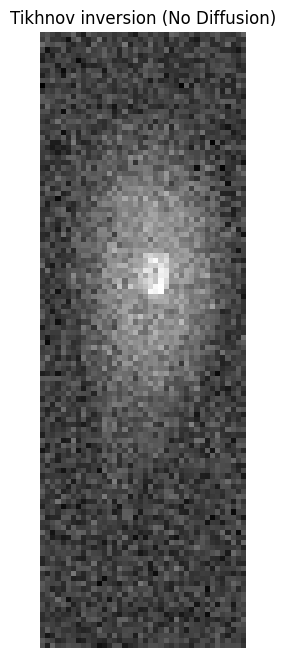

In [43]:
x_without_diffusion = torch.linalg.lstsq(A_torch.T @ A_torch + 1e-2 * torch.eye(A_torch.shape[1], device=device), A_torch.T @ y.reshape(-1)).solution

# 2. Reshape the 1D flat array back into your 120x40 SXR plasma grid
x_without_diffusion = x_without_diffusion.reshape(120, 40)

# 3. Visualize the result
plt.figure(figsize=(5, 8))
plt.imshow(x_without_diffusion.cpu().numpy(), cmap="gray")
plt.title("Tikhnov inversion (No Diffusion)")
plt.axis("off")
plt.show()

In [ ]:
#reconstruction using posterior sampling with DDPM
device = 'cuda:0'
generated_list = []
linearoperator = A_torch
print(linearoperator.shape)
# generated, _ = posterior_generate_image(
#     model.to(device), 
#     sample_size=99, 
#     channel=1, 
#     shape=(120, 40), 
#     linear_operator=A_torch, 
#     y=y, 
#     lambda_val=10000,   # Increase to force tighter adherence to measurements 'y'
#     sigma_n=0.01,     # Estimated noise standard deviation in your measurements
#     zeta=1          # Controls stochasticity (0.0 = DDIM, 1.0 = standard DDPM)
# )
generated, _ = generate_image(
    model,
    sample_size=99,
    channel=100000,
    shape=(120, 40),
    linear_operator=A_torch,   # your [n_obs, 4800] matrix already on device
    y=y,                       # your observation vector, shape [n_obs]
    step_size=0.1              # tune this: larger → more data fit, smaller → more prior
)
generated_list.append(generated)

generated_list = np.array(generated_list)
    

torch.Size([4800, 4800])


(120, 40)


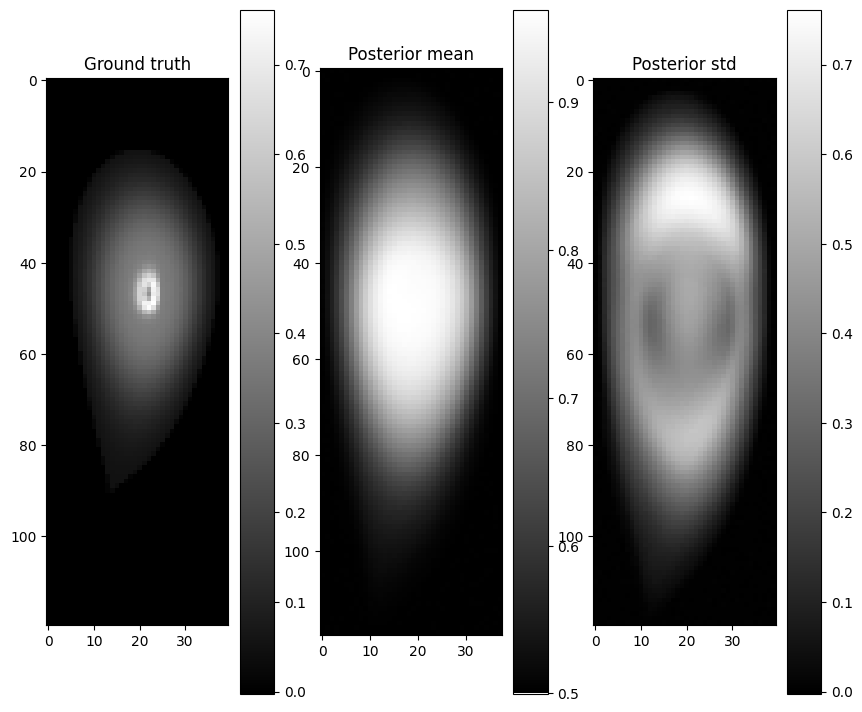

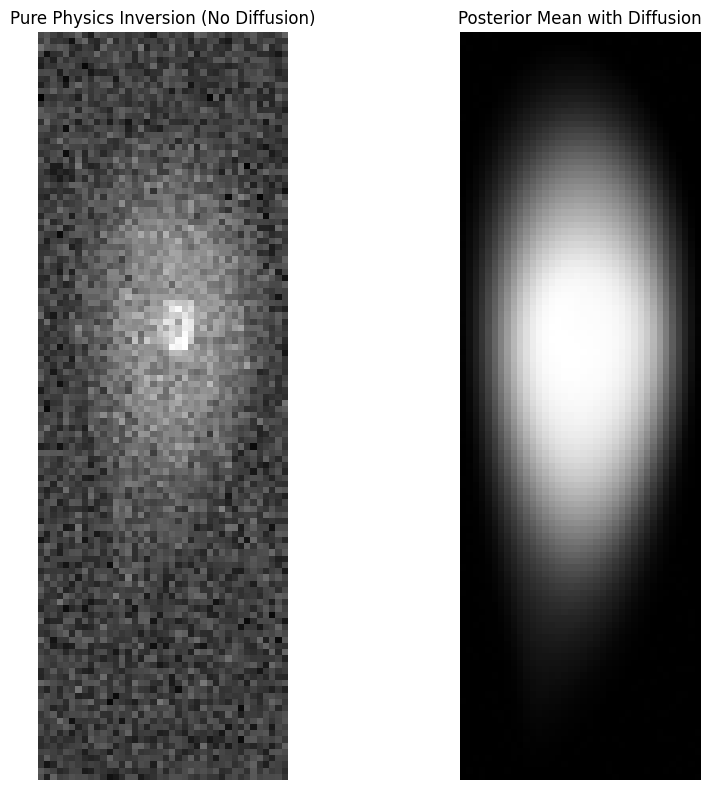

In [ ]:
generated_list = generated_list.squeeze()
fig, ax = plt.subplots(1, 3, figsize=(10, 15))

c0 = ax[0].imshow(x_gt_np, cmap="gray")
ax[0].set_title("Ground truth")

posterior_mean = np.mean(generated_list, axis=0)

c1 = ax[1].imshow(posterior_mean.squeeze()[1:-1, 1:-1], cmap="gray")
ax[1].set_title("Posterior mean")

std_image = np.std(generated_list, axis=0)
print(std_image.shape)
ax[2].imshow(rescale(std_image).squeeze(), cmap="gray")
ax[2].set_title("Posterior std")
fig.colorbar(c1, ax= ax[2])
fig.colorbar(c0, ax= ax[1])
fig.colorbar(c1, ax= ax[0])

# Add plot without diffusion
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 8))
ax2[0].imshow(x_without_diffusion.cpu().numpy(), cmap="gray")
ax2[0].set_title("Pure Physics Inversion (No Diffusion)")
ax2[0].axis("off")
ax2[1].imshow(posterior_mean.squeeze()[1:-1, 1:-1], cmap="gray")
ax2[1].set_title("Posterior Mean with Diffusion")
ax2[1].axis("off")
plt.tight_layout()
plt.show()

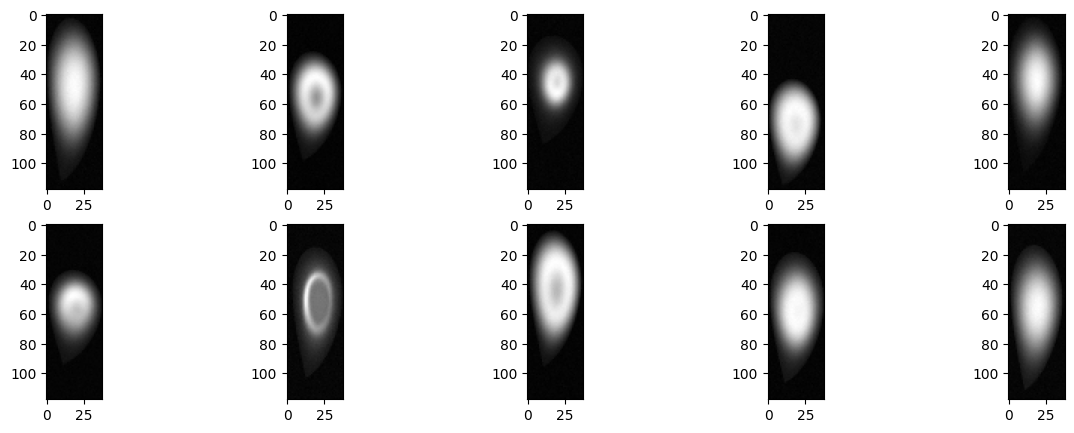

In [ ]:
#show_images_rescale(generated, "final results")
fig, ax = plt.subplots(2, 5, figsize=(15, 5))
for i in range(5):
    ax[0, i].imshow(generated_list[i].squeeze()[1:-1, 1:-1], cmap="gray")
    ax[1, i].imshow(generated_list[i+5].squeeze()[1:-1, 1:-1], cmap="gray")

plt.show()